<a href="https://colab.research.google.com/github/ZIZOHH-008/Machine-Learning-Domestika/blob/main/RegresionLineal_CaliforniaHouses.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#
#
#   ANÁLISIS DE DATOS (Explicado en otro colab)
#
#

In [ ]:
import pandas as pd
import seaborn
datos = pd.read_csv("CaliforniaHouses.csv")
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
datos.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
datos["ocean_proximity"]

,ocean_proximity
0,NEAR BAY
1,NEAR BAY
2,NEAR BAY
3,NEAR BAY
4,NEAR BAY
...,...
20635,INLAND
20636,INLAND
20637,INLAND
20638,INLAND


In [ ]:
datos["ocean_proximity"].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


In [ ]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
datosSinHuecos = datos.dropna()
datosSinHuecos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


In [ ]:
dummies = pd.get_dummies(datosSinHuecos["ocean_proximity"], dtype=int)
print(dummies)

       <1H OCEAN  INLAND  ISLAND  NEAR BAY  NEAR OCEAN
0              0       0       0         1           0
1              0       0       0         1           0
2              0       0       0         1           0
3              0       0       0         1           0
4              0       0       0         1           0
...          ...     ...     ...       ...         ...
20635          0       1       0         0           0
20636          0       1       0         0           0
20637          0       1       0         0           0
20638          0       1       0         0           0
20639          0       1       0         0           0

[20433 rows x 5 columns]


In [ ]:
datosSinHuecos.join(dummies)
datosBuenos = datosSinHuecos.join(dummies)

In [ ]:
datosBuenos.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,0,0,0,1,0


In [ ]:
datosLimpios = datosBuenos.drop("ocean_proximity", axis=1)
datosLimpios.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,0,1,0


In [ ]:
datosLimpios.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
count,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000
mean,-119.570689,35.633221,28.633094,2636.504233,537.870553,1424.946949,499.433465,3.871162,206864.413155,0.442128,0.317917,0.000245,0.111095,0.128615
std,2.003578,2.136348,12.591805,2185.269567,421.385070,1133.208490,382.299226,1.899291,115435.667099,0.496652,0.465678,0.015641,0.314257,0.334782
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-121.800000,33.930000,18.000000,1450.000000,296.000000,787.000000,280.000000,2.563700,119500.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.536500,179700.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,-118.010000,37.720000,37.000000,3143.000000,647.000000,1722.000000,604.000000,4.744000,264700.000000,1.000000,1.000000,0.000000,0.000000,0.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000,1.000000,1.000000,1.000000,1.000000,1.000000


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

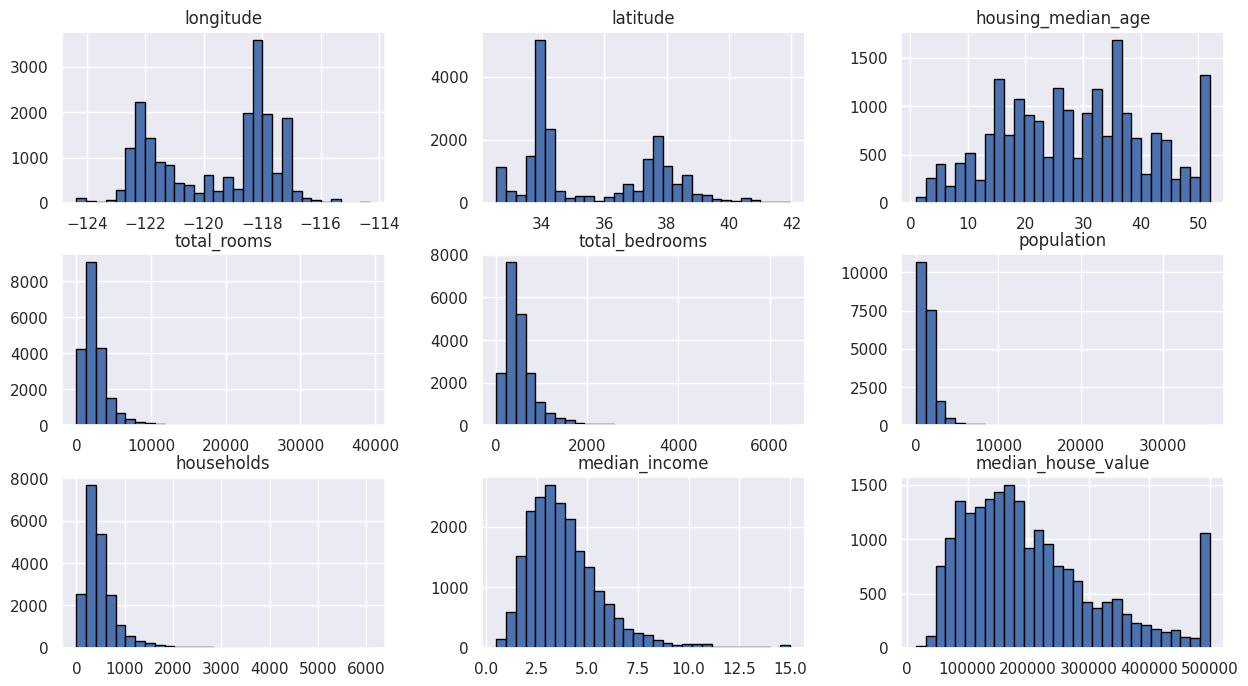

In [ ]:
datos.hist(figsize=(15,8), bins=30, edgecolor="Black")

TypeError: cannot convert the series to <class 'float'>

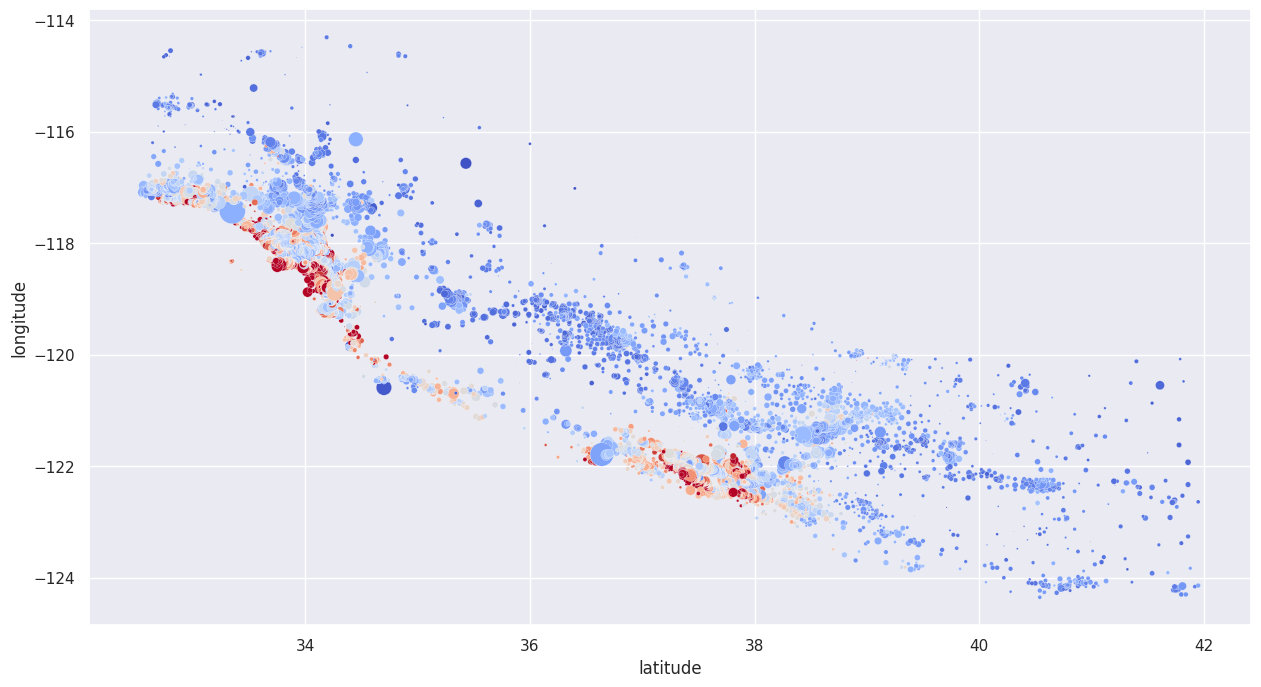

In [ ]:
seaborn.scatterplot(x="latitude", y="longitude", data=datos, hue="median_house_value", palette="coolwarm",
               s=datos["population"]/100)

<Axes: xlabel='latitude', ylabel='longitude'>

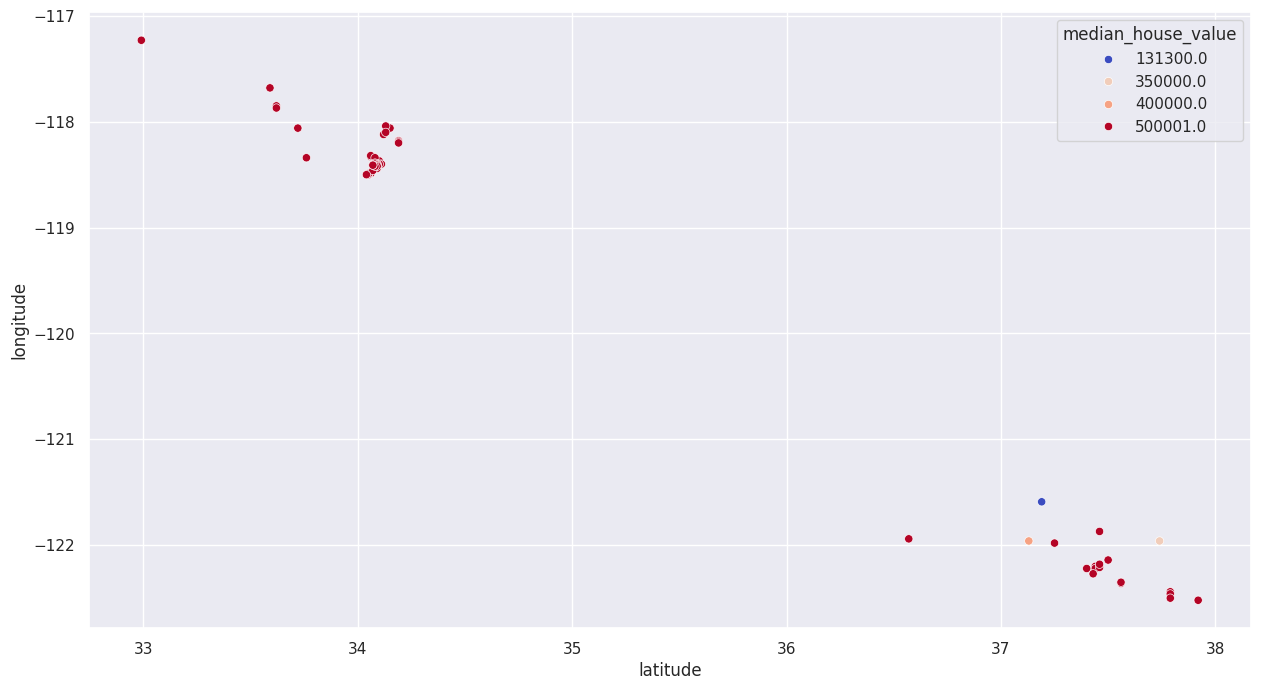

In [ ]:
seaborn.scatterplot(x="latitude", y="longitude", data=datos[(datos.median_income>14)], hue="median_house_value", palette="coolwarm")


In [ ]:
datosLimpios.corr()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
longitude,1.000000,-0.924616,-0.109357,0.045480,0.069608,0.100270,0.056513,-0.015550,-0.045398,0.320831,-0.055337,0.009501,-0.474714,0.046185
latitude,-0.924616,1.000000,0.011899,-0.036667,-0.066983,-0.108997,-0.071774,-0.079626,-0.144638,-0.446928,0.351084,-0.016662,0.358785,-0.161342
housing_median_age,-0.109357,0.011899,1.000000,-0.360628,-0.320451,-0.295787,-0.302768,-0.118278,0.106432,0.045553,-0.236968,0.017105,0.256149,0.020797
total_rooms,0.045480,-0.036667,-0.360628,1.000000,0.930380,0.857281,0.918992,0.197882,0.133294,-0.003777,0.026477,-0.007603,-0.023647,-0.008674
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686,0.018314,-0.006463,-0.004361,-0.019873,0.000679
population,0.100270,-0.108997,-0.295787,0.857281,0.877747,1.000000,0.907186,0.005087,-0.025300,0.073450,-0.019602,-0.010451,-0.061480,-0.023498
households,0.056513,-0.071774,-0.302768,0.918992,0.979728,0.907186,1.000000,0.013434,0.064894,0.041883,-0.038265,-0.009119,-0.011280,0.002106
median_income,-0.015550,-0.079626,-0.118278,0.197882,-0.007723,0.005087,0.013434,1.000000,0.688355,0.168715,-0.237536,-0.009281,0.056677,0.027351
median_house_value,-0.045398,-0.144638,0.106432,0.133294,0.049686,-0.025300,0.064894,0.688355,1.000000,0.257614,-0.484787,0.023525,0.160526,0.140378
<1H OCEAN,0.320831,-0.446928,0.045553,-0.003777,0.018314,0.073450,0.041883,0.168715,0.257614,1.000000,-0.607778,-0.013928,-0.314721,-0.342018


<Axes: >

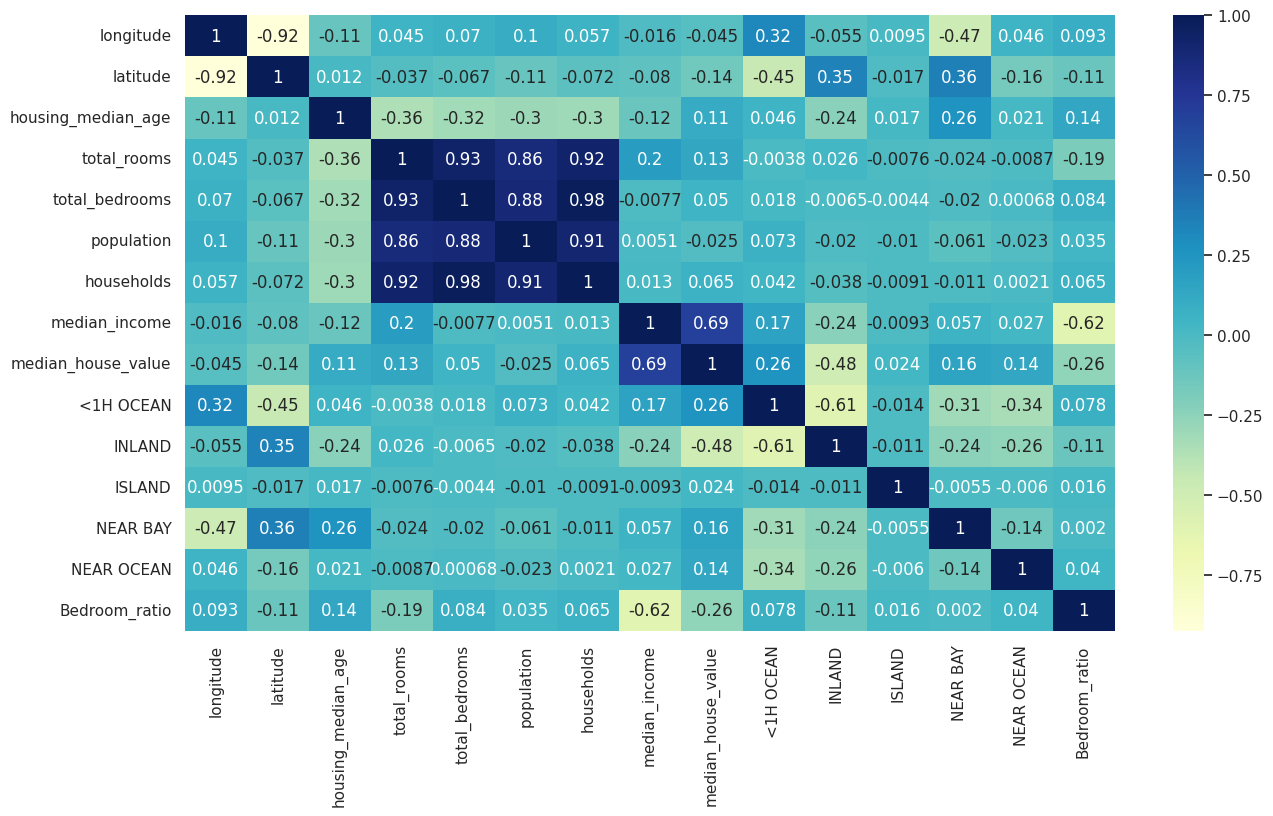

In [ ]:
seaborn.set(rc={'figure.figsize': (15,8)})
seaborn.heatmap(datosLimpios.corr(), annot=True, cmap="YlGnBu")

In [ ]:
datosLimpios.corr()["median_house_value"].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.688355
<1H OCEAN,0.257614
NEAR BAY,0.160526
NEAR OCEAN,0.140378
total_rooms,0.133294
housing_median_age,0.106432
households,0.064894
total_bedrooms,0.049686
ISLAND,0.023525


In [ ]:
#
#
#   LA REGRESIÓN LINEAL
#
#

<Axes: xlabel='median_house_value', ylabel='median_income'>

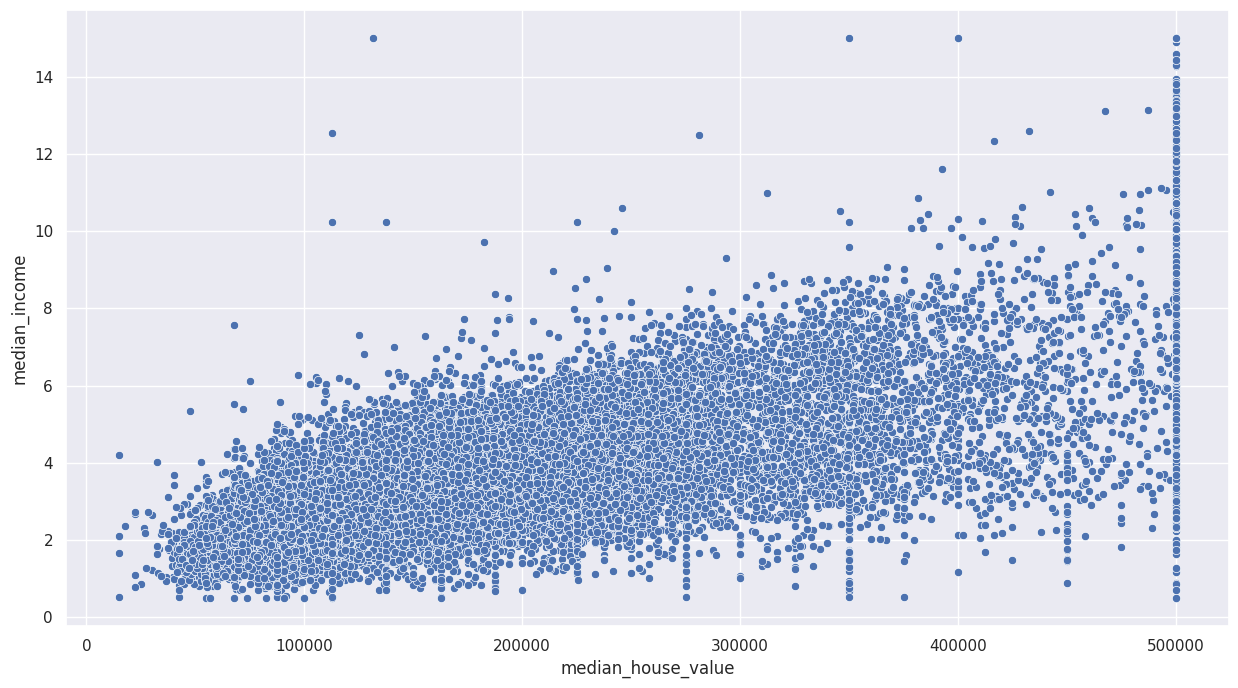

In [ ]:
seaborn.scatterplot(x=datosLimpios["median_house_value"], y=datosLimpios["median_income"])

In [ ]:
# Si miramos la correlación, el numero de habitaciones para dormir no afectan casi el precio (0.05), pero el total de habitaciones sí (0.15)
# Se van a añadir una nueva caracteristicas

In [ ]:
# Nueva caracteristica: Cuantos de los cuartos son cuartos pra dormir
datosLimpios["Bedroom_ratio"] = datosLimpios["total_bedrooms"] / datosLimpios["total_rooms"]

<Axes: >

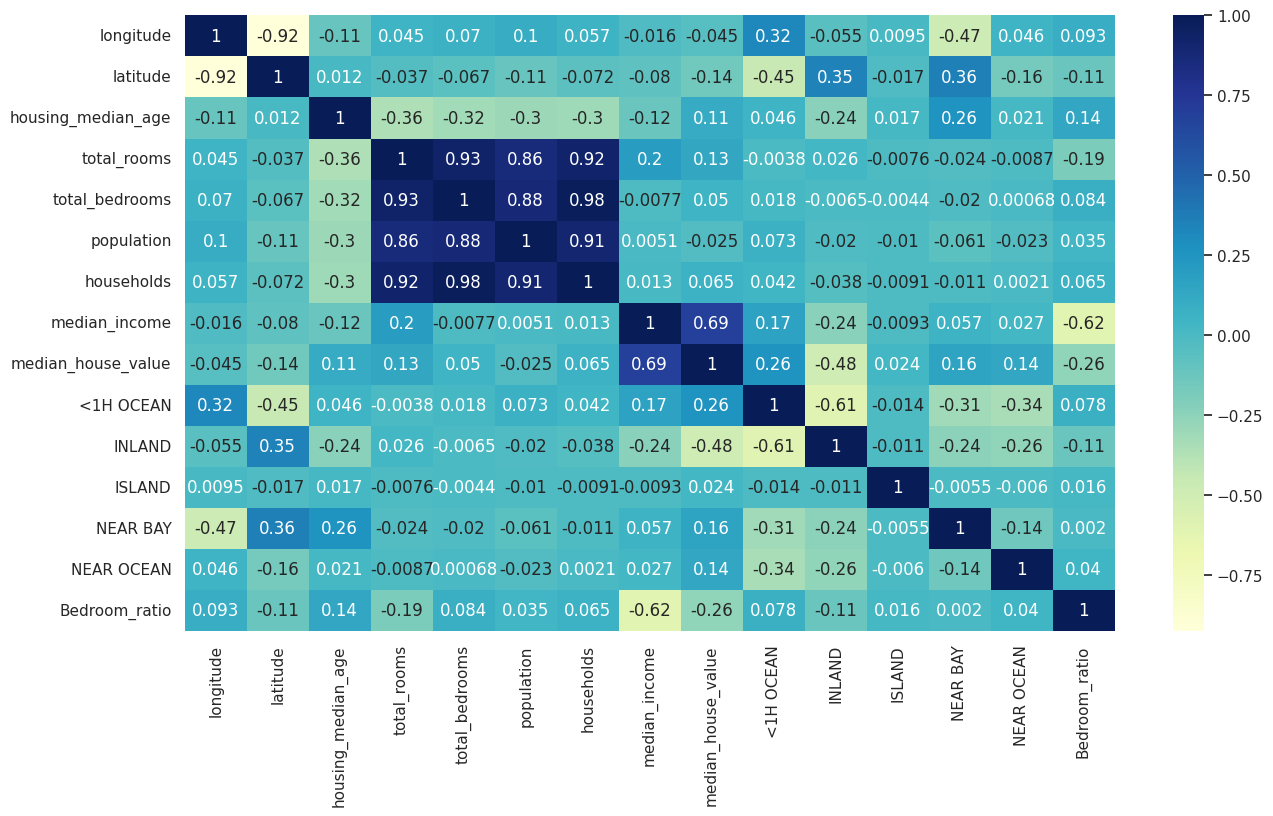

In [ ]:
seaborn.set(rc={'figure.figsize': (15,8)})
seaborn.heatmap(datosLimpios.corr(), annot=True, cmap="YlGnBu")

# Entre menos de los cuartos sean para dormir, más cuesta la casa

In [ ]:
# Separar las caracteristicas de la etiqueta
x = datosLimpios.drop(["median_house_value"], axis=1)
y = datosLimpios["median_house_value"]

# Datos para predecir: Las X
# Datos de resultado: Las Y

In [ ]:
# Separar los datos en dos partes: Conjunto de entrenamiento y de prueba
from sklearn.model_selection import train_test_split

x_entrenamiento, x_prueba, y_entrenamiento, y_prueba = train_test_split(x, y, test_size=0.2)
#Solo la funcion de train_test devuelve 4 valores los cuales se almacenan en esas variables

In [ ]:
x_entrenamiento.shape

(16346, 14)

In [ ]:
y_entrenamiento.shape   # ambas tienen iguales registros pero columnas distintas (igual pasa con las de )

(16346,)

In [ ]:
from sklearn.linear_model import LinearRegression
modelo = LinearRegression()
# Se creó el modelo, falta entrenar

In [ ]:
modelo.fit(x_entrenamiento, y_entrenamiento)

LinearRegression()

In [ ]:
predicciones = modelo.predict(x_prueba) # Se hace la predicción en base al conjunto de pruebas, para compararlo con el resultado de pruebas (y_prueba)

In [ ]:
pd.DataFrame(predicciones)
#Predicciones por sí solo es un array, con lo de pandas los ponen en una tabla

,0
0,288348.985048
1,160061.577241
2,80930.702267
3,270859.291849
4,226715.631686
...,...
4082,318135.494698
4083,206725.730527
4084,127168.147464
4085,86404.336739


In [ ]:
comparativa = {"Predicción: ": predicciones,
               "Valor_real: ": y_prueba}          # Un diccionario


pd.DataFrame(comparativa)

,Predicción:,Valor_real:
8386,288348.985048,246300.0
12741,160061.577241,159500.0
1181,80930.702267,41800.0
8044,270859.291849,219500.0
15211,226715.631686,216800.0
...,...,...
11396,318135.494698,301800.0
15792,206725.730527,312500.0
20019,127168.147464,99200.0
12132,86404.336739,130900.0


In [ ]:
# Overfitting - SobreAjuste
'''
Si funciona muy bien con los datos de entrenamiento y funciona mal con los datos de prueba
Se aprende los datos de entrenamiento pero no es capaz de generalizar con datos de prueba
'''

In [ ]:
# En este caso, ambos tienen una precisión muy similar
print(modelo.score(x_entrenamiento, y_entrenamiento))
print(modelo.score(x_prueba, y_prueba))

0.6583523973164085
0.6231335011946024


In [ ]:
# Error - Tomar los datos de las predicciones y los valores reales para calcular que tanto se está errando
from sklearn.metrics import mean_squared_error
import numpy

mse = mean_squared_error(y_prueba, predicciones)  # Compara el valor de salida de la predicción con el valor de salida de la prueba

In [ ]:
mse
# Al ser una medición del error por MINIMOS CUADRADOS, los valores de error quedan el cuadrado y son enormes

5052496288.999529

In [ ]:
Raiz_mse = numpy.sqrt(mse)
Raiz_mse    #Este es el promedio de lo que estamos fallando al estimar el precio

np.float64(71080.91367589142)

In [ ]:
  # Scaler (Escalamiento)
'''
  La antiguedad de la casa siempre está entre 1 y 52 años
  La población puede variar entre 3 y 35k
  Al entrenar un modelo, estos le dan mayor peso a los datos que son más grandes

  "Scarler" los pone en rangos pequeños para que la diferenica entre 1 y 52 sea la misma entre 3 y 35k
  Así al entrenar, no se le da la prioridad por mayoría numérica
'''

datosLimpios.describe()

'\nLa antiguedad de la casa siempre está entre 1 y 52 años\nLa población puede variar entre 3 y 35k\nAl entrenar un modelo, estos le dan mayor peso a los datos que son más grandes\n\n"Scarler" los pone en rangos pequeños para que la diferenica entre 1 y 52 sea la misma entre 3 y 35k\nAsí al entrenar, no se le da la prioridad por mayoría numérica\n'

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_entrenamiento_escalada = scaler.fit_transform(x_entrenamiento)
x_prueba_escalada = scaler.fit_transform(x_prueba)

In [ ]:
x_entrenamiento

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN,Bedroom_ratio
3071,-119.25,35.78,35.0,1927.0,386.0,1371.0,414.0,2.2981,0,1,0,0,0,0.200311
2237,-119.81,36.85,17.0,2340.0,370.0,1174.0,396.0,4.2304,0,1,0,0,0,0.158120
16955,-122.30,37.53,40.0,1833.0,308.0,751.0,306.0,6.0000,0,0,0,0,1,0.168031
7638,-118.29,33.81,19.0,7023.0,1538.0,3993.0,1412.0,5.0532,1,0,0,0,0,0.218995
17838,-121.90,37.44,4.0,1646.0,408.0,853.0,410.0,5.0821,1,0,0,0,0,0.247874
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2240,-119.81,36.83,19.0,6789.0,1200.0,2325.0,1109.0,4.0490,0,1,0,0,0,0.176757
1514,-122.06,37.90,25.0,5869.0,1685.0,2669.0,1554.0,2.6998,0,0,0,1,0,0.287102
14822,-117.12,32.66,52.0,16.0,4.0,8.0,3.0,1.1250,0,0,0,0,1,0.250000
13718,-117.19,34.08,5.0,4458.0,751.0,2392.0,773.0,4.5938,0,1,0,0,0,0.168461


In [ ]:
pd.DataFrame(x_entrenamiento_escalada)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,0.154614,0.074358,0.505050,-0.326600,-0.360977,-0.045622,-0.223112,-0.831706,-0.888251,1.463231,-0.013549,-0.352652,-0.386244,-0.216760
1,-0.125019,0.576669,-0.924097,-0.135768,-0.399173,-0.226376,-0.270474,0.186631,-0.888251,1.463231,-0.013549,-0.352652,-0.386244,-0.942947
2,-1.368384,0.895894,0.902036,-0.370034,-0.547184,-0.614494,-0.507287,1.119223,-0.888251,-0.683419,-0.013549,-0.352652,2.589037,-0.772365
3,0.633984,-0.850458,-0.765303,2.028071,2.389172,2.360158,2.402877,0.620252,1.125808,-0.683419,-0.013549,-0.352652,-0.386244,0.104811
4,-1.168646,0.853644,-1.956260,-0.456439,-0.308456,-0.520905,-0.233637,0.635483,1.125808,-0.683419,-0.013549,-0.352652,-0.386244,0.601863
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16341,-0.125019,0.567280,-0.765303,1.919949,1.582271,0.829708,1.605608,0.091031,-0.888251,1.463231,-0.013549,-0.352652,-0.386244,-0.622177
16342,-1.248541,1.069590,-0.288921,1.494851,2.740102,1.145340,2.776514,-0.620007,-0.888251,-0.683419,-0.013549,2.835653,-0.386244,1.277041
16343,1.218215,-1.390324,1.854801,-1.209601,-1.272918,-1.296223,-1.304556,-1.449939,-0.888251,-0.683419,-0.013549,-0.352652,2.589037,0.638461
16344,1.183261,-0.723706,-1.876862,0.842881,0.510381,0.891183,0.721507,0.378145,-0.888251,1.463231,-0.013549,-0.352652,-0.386244,-0.764953


In [ ]:
modelo_escalado = LinearRegression()
modelo.fit(x_entrenamiento_escalada, y_entrenamiento)

LinearRegression()

In [ ]:
predicciones = modelo.predict(x_prueba)
pd.DataFrame(predicciones)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


,0
0,-7.628165e+06
1,-4.723981e+06
2,-3.091813e+05
3,-7.641370e+06
4,-2.135262e+07
...,...
4082,-3.632484e+07
4083,-1.984364e+07
4084,-2.608265e+07
4085,-1.896951e+08
